Connect ke Google Drive & Set Directory

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Path Folder Dataset dan Folder Penyimpanan Model di Drive Anda
DATASET_DIR = '/content/drive/MyDrive/DEEP LEARNING/Dataset_Cabai'
SAVE_MODEL_DIR = '/content/drive/MyDrive/DEEP LEARNING/Saved_Models'

os.makedirs(SAVE_MODEL_DIR, exist_ok=True)
print("Penyimpanan Google Drive Siap!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Penyimpanan Google Drive Siap!


Load Path Citra & Manual Stratified Split (70:15:15)

In [ ]:
import os
import glob
import shutil
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# 1. Path asal (Drive) & Path tujuan (Disk Lokal Colab)
DRIVE_DATASET_DIR = '/content/drive/MyDrive/DEEP LEARNING/Dataset_Cabai'
LOCAL_DATASET_DIR = '/tmp/Dataset_Cabai'

# 2. Salin dataset dari Drive ke Disk Lokal Colab
if not os.path.exists(LOCAL_DATASET_DIR):
    print("Menyalin dataset dari Google Drive ke Disk Lokal Colab...")
    shutil.copytree(DRIVE_DATASET_DIR, LOCAL_DATASET_DIR)
    print("Salin dataset selesai!")
else:
    print("Dataset sudah tersedia di Disk Lokal Colab.")

# 3. Ambil daftar path gambar dari FOLDER LOKAL
filepaths = []
labels = []

class_names = sorted([d for d in os.listdir(LOCAL_DATASET_DIR) if os.path.isdir(os.path.join(LOCAL_DATASET_DIR, d))])
class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}
NUM_CLASSES = len(class_names)

for cls_name in class_names:
    cls_dir = os.path.join(LOCAL_DATASET_DIR, cls_name)
    for img_path in glob.glob(os.path.join(cls_dir, '*.*')):
        filepaths.append(img_path)
        labels.append(class_to_idx[cls_name])

filepaths = np.array(filepaths)
labels = np.array(labels)

# 4. Split Manual 70% Train, 15% Val, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(
    filepaths, labels, test_size=0.30, random_state=42, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Total Citra       : {len(filepaths)}")
print(f"Data Train (70%)  : {len(X_train)}")
print(f"Data Val   (15%)  : {len(X_val)}")
print(f"Data Test  (15%)  : {len(X_test)}")
print(f"Nama Kelas        : {class_names}")

# 5. Pipeline tf.data dengan .cache() untuk Akses Cepat
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def parse_image(filename, label):
    image = tf.io.read_file(filename)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize_with_pad(image, IMG_SIZE[0], IMG_SIZE[1], antialias=True)
    image = tf.cast(tf.round(image), tf.uint8)
    return image, label

def create_tf_dataset(x, y, is_training=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache() # cache SEBELUM shuffle & batch
    if is_training:
        ds = ds.shuffle(buffer_size=len(x), reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_tf_dataset(X_train, y_train, is_training=True)
val_ds = create_tf_dataset(X_val, y_val)
test_ds = create_tf_dataset(X_test, y_test)

Dataset sudah tersedia di Disk Lokal Colab.
Total Citra       : 1515
Data Train (70%)  : 1060
Data Val   (15%)  : 227
Data Test  (15%)  : 228
Nama Kelas        : ['Anthracnose', 'Cercospora Leaf Spot', 'Fresh Leaf', 'Leaf Curl Disease']


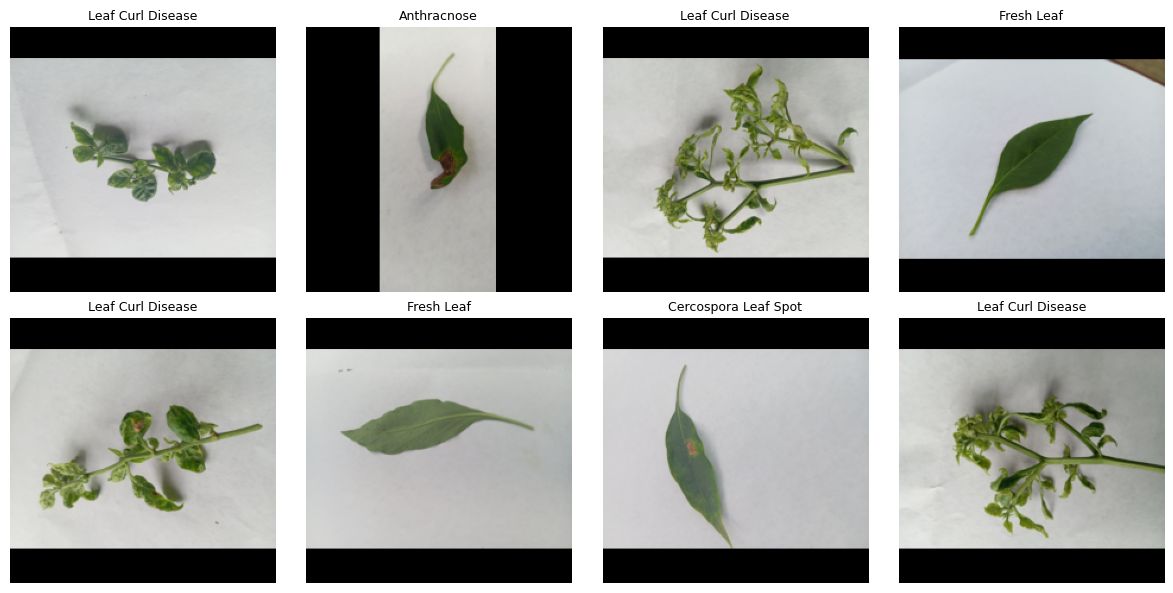

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(8):
    img, _ = parse_image(X_test[i], 0)
    plt.subplot(2, 4, i + 1)
    plt.imshow(img.numpy())
    plt.title(class_names[y_test[i]], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

pembersihan kebocoran

jarak < 0.05: test=  2 | val=  4
jarak < 0.1 : test=  6 | val= 10
jarak < 0.15: test= 17 | val= 20
jarak < 0.2 : test= 37 | val= 43
jarak < 0.3 : test=104 | val=101


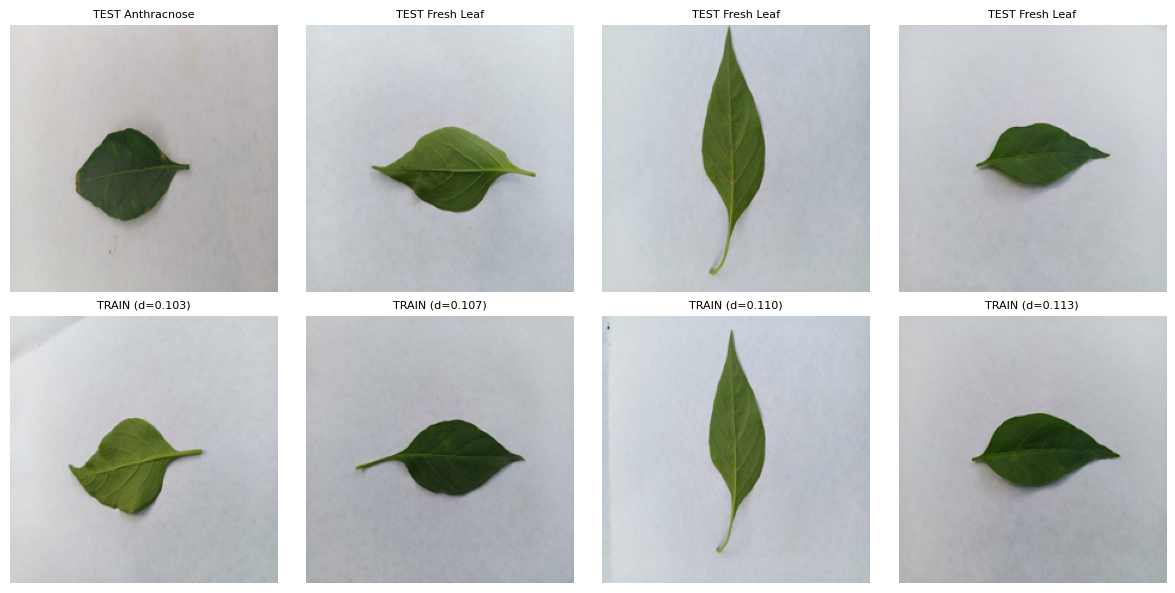

In [ ]:
from PIL import Image

# ---------- 1. Fungsi thumbnail ----------
def thumb(path, size=32):
    im = Image.open(path)
    im.draft('RGB', (size * 4, size * 4))      # percepat decode JPEG besar
    im = im.convert('L').resize((size, size))
    a = np.asarray(im, dtype=np.float32).ravel()
    return (a - a.mean()) / (a.std() + 1e-6)

def min_dist_to_train(paths):
    t = np.stack([thumb(p) for p in paths])
    d = ((t[:, None, :] - tr_t[None, :, :]) ** 2).mean(axis=2)
    return d.min(axis=1), d.argmin(axis=1)

tr_t = np.stack([thumb(p) for p in X_train])
d_te, idx_te = min_dist_to_train(X_test)
d_va, idx_va = min_dist_to_train(X_val)

# ---------- 2. Sebaran kebocoran ----------
for th in [0.05, 0.1, 0.15, 0.2, 0.3]:
    print(f"jarak < {th:<4}: test={int((d_te < th).sum()):>3} | val={int((d_va < th).sum()):>3}")

# ---------- 3. Lihat pasangan di zona abu-abu (0.1 - 0.3) ----------
grey = np.where((d_te >= 0.1) & (d_te < 0.3))[0]
sel = grey[np.argsort(d_te[grey])][:4]
plt.figure(figsize=(12, 6))
for k, i in enumerate(sel):
    plt.subplot(2, 4, k + 1); plt.imshow(Image.open(X_test[i]).resize((224, 224)))
    plt.title(f"TEST {class_names[y_test[i]]}", fontsize=8); plt.axis('off')
    plt.subplot(2, 4, k + 5); plt.imshow(Image.open(X_train[idx_te[i]]).resize((224, 224)))
    plt.title(f"TRAIN (d={d_te[i]:.3f})", fontsize=8); plt.axis('off')
plt.tight_layout(); plt.show()

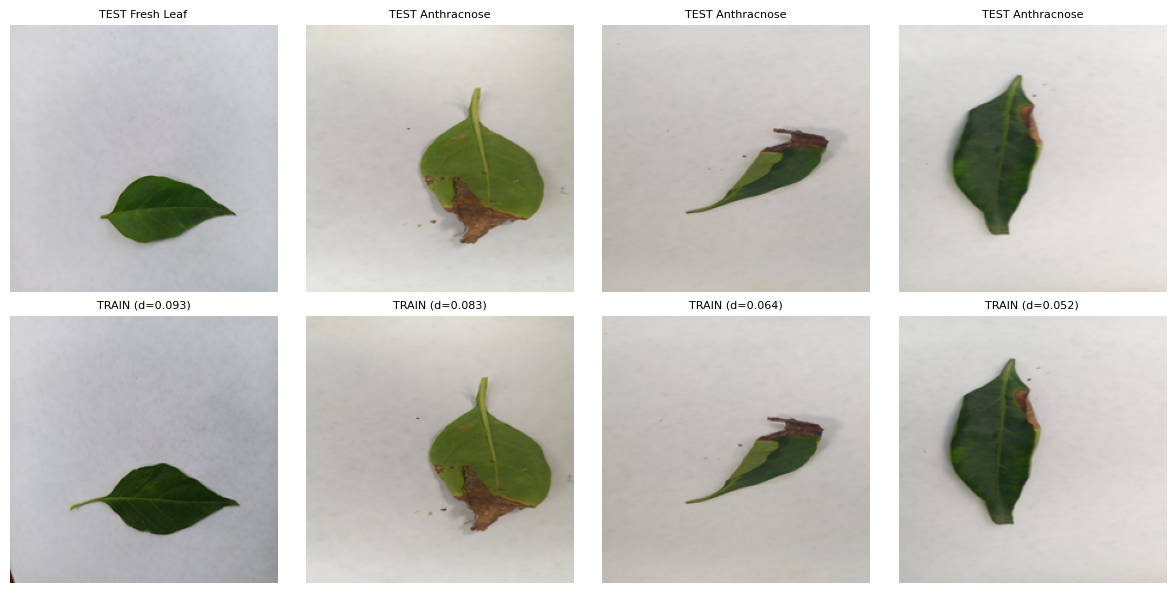

In [ ]:
zone = np.where((d_te >= 0.05) & (d_te < 0.10))[0]
sel = zone[np.argsort(-d_te[zone])][:4]     # yang paling dekat ke 0.10
plt.figure(figsize=(12, 6))
for k, i in enumerate(sel):
    plt.subplot(2, 4, k + 1); plt.imshow(Image.open(X_test[i]).resize((224, 224)))
    plt.title(f"TEST {class_names[y_test[i]]}", fontsize=8); plt.axis('off')
    plt.subplot(2, 4, k + 5); plt.imshow(Image.open(X_train[idx_te[i]]).resize((224, 224)))
    plt.title(f"TRAIN (d={d_te[i]:.3f})", fontsize=8); plt.axis('off')
plt.tight_layout(); plt.show()

Terapkan pembersihan

In [ ]:
THRESH = 0.10

keep_te = d_te >= THRESH
keep_va = d_va >= THRESH
print(f"Test: {keep_te.sum()}/{len(X_test)} dipertahankan | Val: {keep_va.sum()}/{len(X_val)} dipertahankan")

X_test, y_test = X_test[keep_te], y_test[keep_te]
X_val,  y_val  = X_val[keep_va],  y_val[keep_va]

val_ds  = create_tf_dataset(X_val, y_val)
test_ds = create_tf_dataset(X_test, y_test)

print("Distribusi test :", np.bincount(y_test, minlength=NUM_CLASSES))
print("Distribusi val  :", np.bincount(y_val, minlength=NUM_CLASSES))

Test: 222/228 dipertahankan | Val: 217/227 dipertahankan
Distribusi test : [47 55 64 56]
Distribusi val  : [45 55 62 55]


Pembangunan Arsitektur Model (Custom CNN & MobileNetV3-Small)

In [ ]:
# 1. Custom CNN (Skenario 1)
def build_custom_cnn():
    inputs = layers.Input(shape=(*IMG_SIZE, 3))
    x = layers.Rescaling(1./255)(inputs)
    x = layers.Conv2D(32, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Conv2D(128, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(inputs=inputs, outputs=outputs)

# 2. Pipeline MobileNetV3-Small (Skenario 2, 3, 4)
def build_mobilenetv3_pipeline(use_aug=False):
    inputs = layers.Input(shape=(*IMG_SIZE, 3))
    x = inputs

    # Data Augmentation terukur
    if use_aug:
        x = layers.RandomFlip("horizontal_and_vertical")(x)
        x = layers.RandomRotation(0.25)(x)
        x = layers.RandomZoom(0.2)(x)
        x = layers.RandomTranslation(0.1, 0.1)(x)
        x = layers.RandomBrightness(0.2, value_range=(0, 255))(x)
        x = layers.RandomContrast(0.2)(x)

    # Preprocessing bawaan MobileNetV3
    x = tf.keras.applications.mobilenet_v3.preprocess_input(x)

    base_model = tf.keras.applications.MobileNetV3Small(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze layer dasar

    x = base_model(x, training=False)   # <-- perubahan wajib
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return models.Model(inputs=inputs, outputs=outputs), base_model

print("Arsitektur Model Berhasil Disiapkan!")

Arsitektur Model Berhasil Disiapkan!


Eksekusi Pelatihan 4 Skenario
1. S1: Custom CNN dari nol, tanpa augmentasi, Adam (lr=1e-3), 15 epoch.
2. S2: MobileNetV3-Small pretrained frozen, tanpa augmentasi, Adam (lr=1e-3), 15 epoch.
3. S3: MobileNetV3-Small frozen, augmentasi (flip horizontal dan vertikal, rotasi ±25%, zoom 20%, translasi 10%, brightness 20%, kontras 20%), Adam (lr=1e-3), 15 epoch.
4. S4: MobileNetV3-Small dengan augmentasi seperti S3. Warm-up 5 epoch (lr=1e-3, base beku), lalu fine-tuning 25 epoch dengan 30 layer teratas dibuka (BatchNorm tetap beku) dan Adam (lr=2e-5). Total 30 epoch.

In [ ]:
import time

histories = {}
trained_models = {}
eval_results = {}
training_times = {}
EPOCHS = 15

# --- SKENARIO 1: Custom CNN (From Scratch) ---
print("\n========== SKENARIO 1: Custom CNN (From Scratch) ==========")
m1 = build_custom_cnn()
m1.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
h1 = m1.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1)
elapsed_time1 = time.time() - start_time

loss1, acc1 = m1.evaluate(test_ds, verbose=0)
histories["Skenario 1 (Custom CNN)"] = h1
trained_models["Skenario 1 (Custom CNN)"] = m1
eval_results["Skenario 1 (Custom CNN)"] = (loss1, acc1)
training_times["Skenario 1 (Custom CNN)"] = elapsed_time1

# --- SKENARIO 2: MobileNetV3 Baseline ---
print("\n========== SKENARIO 2: MobileNetV3-Small Baseline ==========")
m2, _ = build_mobilenetv3_pipeline(use_aug=False)
m2.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

start_time = time.time() # Start timer
h2 = m2.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1)
elapsed_time2 = time.time() - start_time # Stop timer

loss2, acc2 = m2.evaluate(test_ds, verbose=0)
histories["Skenario 2 (MobileNetV3 Baseline)"] = h2
trained_models["Skenario 2 (MobileNetV3 Baseline)"] = m2
eval_results["Skenario 2 (MobileNetV3 Baseline)"] = (loss2, acc2)
training_times["Skenario 2 (MobileNetV3 Baseline)"] = elapsed_time2

# --- SKENARIO 3: MobileNetV3 + Augmentasi ---
print("\n========== SKENARIO 3: MobileNetV3-Small + Augmentasi ==========")
m3, _ = build_mobilenetv3_pipeline(use_aug=True)
m3.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

start_time = time.time() # Start timer
h3 = m3.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1)
elapsed_time3 = time.time() - start_time # Stop timer

loss3, acc3 = m3.evaluate(test_ds, verbose=0)
histories["Skenario 3 (MobileNetV3 + Aug)"] = h3
trained_models["Skenario 3 (MobileNetV3 + Aug)"] = m3
eval_results["Skenario 3 (MobileNetV3 + Aug)"] = (loss3, acc3)
training_times["Skenario 3 (MobileNetV3 + Aug)"] = elapsed_time3

# --- SKENARIO 4: MobileNetV3 + Fine-Tuning ---
print("\n========== SKENARIO 4: MobileNetV3-Small + Fine-Tuning ==========")
m4, base_m4 = build_mobilenetv3_pipeline(use_aug=True)

start_time = time.time()

# Phase 1: Warm-up (5 epoch)
print("-> Phase 1: Warm-up Classification Head (5 Epochs)...")
m4.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h4_warm = m4.fit(train_ds, validation_data=val_ds, epochs=5, verbose=1)

# Phase 2: Unfreeze Top 30 Layers (25 epoch)
print("-> Phase 2: Unfreeze Top 30 Layers (25 Epochs)...")
base_m4.trainable = True
for layer in base_m4.layers[:-30]:
    layer.trainable = False
for layer in base_m4.layers[-30:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False   # BatchNorm tetap beku

m4.compile(optimizer=tf.keras.optimizers.Adam(2e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h4 = m4.fit(train_ds, validation_data=val_ds, epochs=25, verbose=1)

# Gabungkan riwayat warm-up + fine-tuning (total 30 epoch)
for k in h4.history:
    h4.history[k] = h4_warm.history[k] + h4.history[k]

elapsed_time4 = time.time() - start_time

loss4, acc4 = m4.evaluate(test_ds, verbose=0)
histories["Skenario 4 (Fine-Tuning)"] = h4
trained_models["Skenario 4 (Fine-Tuning)"] = m4
eval_results["Skenario 4 (Fine-Tuning)"] = (loss4, acc4)
training_times["Skenario 4 (Fine-Tuning)"] = elapsed_time4

print(f"Total epoch Skenario 4: {len(h4.history['loss'])} (5 warm-up + 25 fine-tuning)")

# --- SIMPAN MODEL TERBAIK KE GOOGLE DRIVE ---
best_name = min(histories, key=lambda n: min(histories[n].history['val_loss']))
best_model = trained_models[best_name]
print("Model terbaik (berdasarkan val_loss):", best_name)

best_model_path = os.path.join(SAVE_MODEL_DIR, 'MobileNetV3_DaunCabai_BestModel.keras')
best_model.save(best_model_path)


========== SKENARIO 1: Custom CNN (From Scratch) ==========
Epoch 1/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 112s 692ms/step - accuracy: 0.2670 - loss: 1.3517 - val_accuracy: 0.4608 - val_loss: 1.2528
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 33s 58ms/step - accuracy: 0.5491 - loss: 1.0176 - val_accuracy: 0.6912 - val_loss: 0.7389
Epoch 3/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.7000 - loss: 0.6926 - val_accuracy: 0.8525 - val_loss: 0.6908
Epoch 4/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.7660 - loss: 0.6059 - val_accuracy: 0.8525 - val_loss: 0.4710
Epoch 5/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8208 - loss: 0.4941 - val_accuracy: 0.8387 - val_loss: 0.4414
Epoch 6/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8264 - loss: 0.4604 - val_accuracy: 0.8571 - val_loss: 0.4110
Epoch 7/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8330 - loss: 0.4180 - val_accuracy: 0.8710 - val_loss: 0.3611
Epoch 8/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/

Tabel Komparasi Hasil & Kurva Konvergensi


=================== REKAPITULASI HASIL & WAKTU KOMPUTASI ===================
Skenario                            | Test Loss  | Test Acc   | Waktu Training    
--------------------------------------------------------------------------------
Skenario 1 (Custom CNN)             | 0.2723     | 88.74    % | 2m 49s (169.79s)  
Skenario 2 (MobileNetV3 Baseline)   | 0.0188     | 99.55    % | 0m 36s (36.62s)   
Skenario 3 (MobileNetV3 + Aug)      | 0.1360     | 95.95    % | 0m 30s (30.66s)   
Skenario 4 (Fine-Tuning)            | 0.1069     | 95.50    % | 0m 55s (55.38s)   


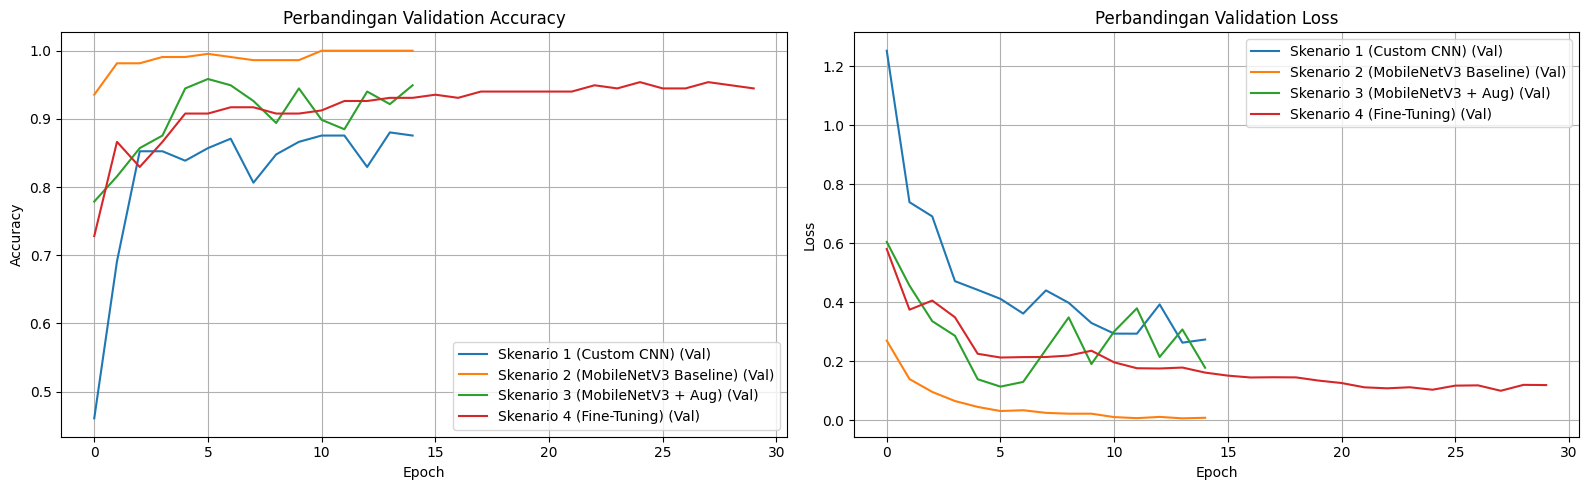

In [ ]:
# Fungsi pembantu merubah detik ke format Menit:Detik
def format_time(seconds):
    minutes = int(seconds // 60)
    sec = int(seconds % 60)
    return f"{minutes}m {sec}s ({seconds:.2f}s)"

# 1. Tampilkan Tabel Rekapitulasi Performa & Waktu Komputasi
print("\n=================== REKAPITULASI HASIL & WAKTU KOMPUTASI ===================")
print(f"{'Skenario':<35} | {'Test Loss':<10} | {'Test Acc':<10} | {'Waktu Training':<18}")
print("-" * 80)
for name, (loss, acc) in eval_results.items():
    t_str = format_time(training_times[name])
    print(f"{name:<35} | {loss:<10.4f} | {acc * 100:<9.2f}% | {t_str:<18}")

# 2. Plot Kurva Akurasi & Loss Perbandingan Skenario
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Accuracy
for name, history in histories.items():
    axes[0].plot(history.history['val_accuracy'], label=f"{name} (Val)")
axes[0].set_title('Perbandingan Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot Loss
for name, history in histories.items():
    axes[1].plot(history.history['val_loss'], label=f"{name} (Val)")
axes[1].set_title('Perbandingan Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Evaluasi Model Terbaik (Classification Report, Confusion Matrix, & ROC Curve)

Model yang dievaluasi: Skenario 2 (MobileNetV3 Baseline)
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 894ms/step

================ CLASSIFICATION REPORT ================
                      precision    recall  f1-score   support

         Anthracnose     1.0000    1.0000    1.0000        47
Cercospora Leaf Spot     1.0000    0.9818    0.9908        55
          Fresh Leaf     0.9846    1.0000    0.9922        64
   Leaf Curl Disease     1.0000    1.0000    1.0000        56

            accuracy                         0.9955       222
           macro avg     0.9962    0.9955    0.9958       222
        weighted avg     0.9956    0.9955    0.9955       222



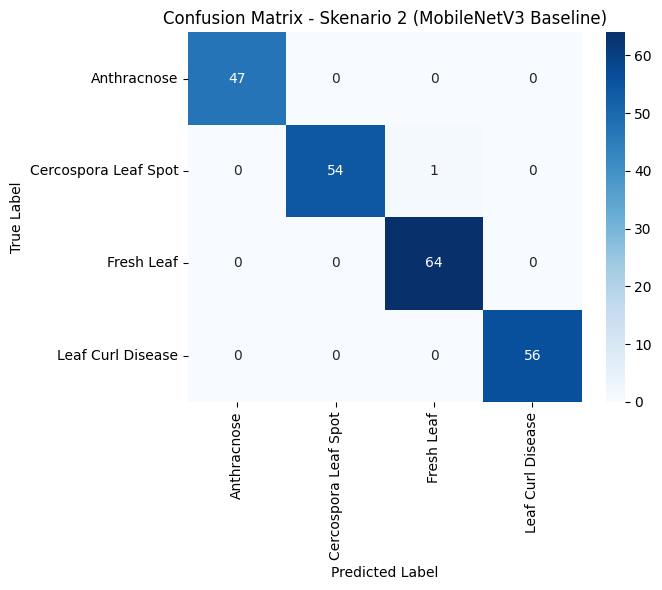

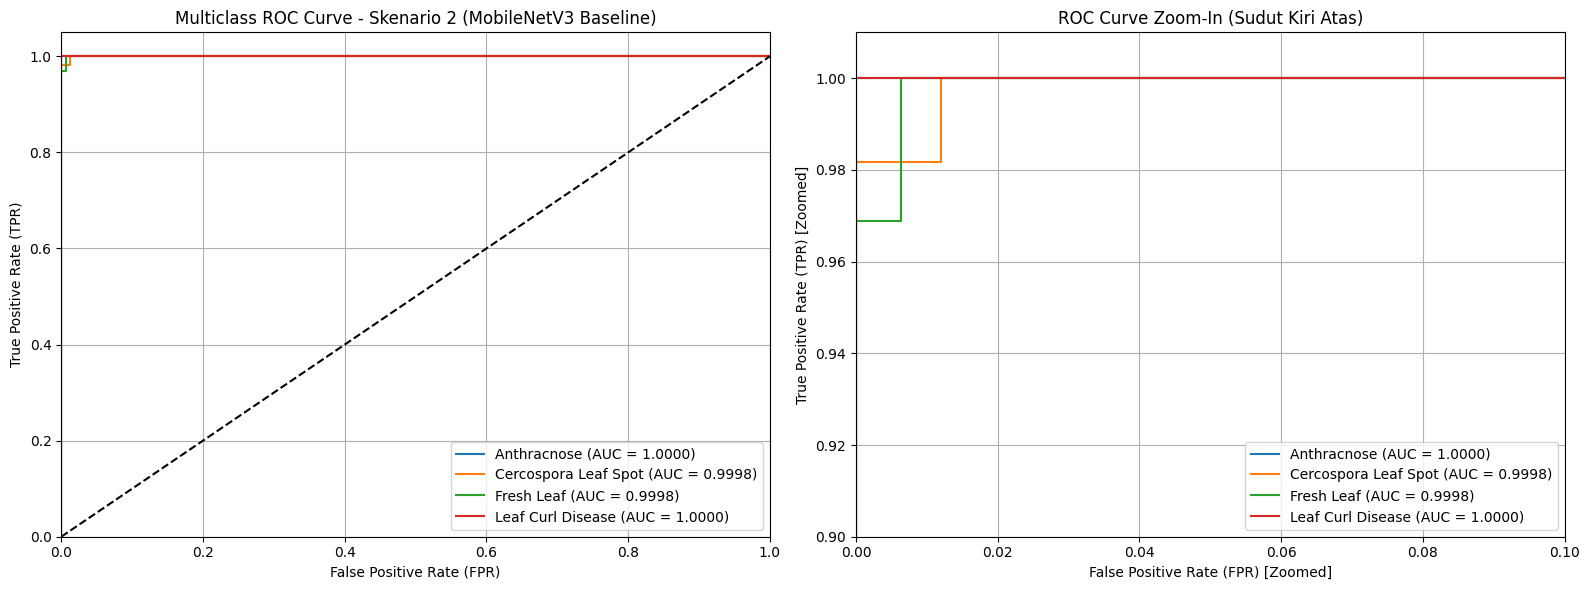

In [ ]:
# Prediksi data uji (pakai model terbaik hasil seleksi otomatis)
print("Model yang dievaluasi:", best_name)
y_pred_probs = best_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# 1. Classification Report
print("\n================ CLASSIFICATION REPORT ================")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# 2. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# 3. Plot ROC Curve dengan Zoom-In Sudut Kiri Atas
y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes=NUM_CLASSES)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Hitung ROC sekali, dipakai untuk kedua subplot
roc_data = []
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_onehot[:, i], y_pred_probs[:, i])
    roc_data.append((fpr, tpr, auc(fpr, tpr)))

# Subplot 1: ROC Curve Keseluruhan
for i, (fpr, tpr, roc_auc) in enumerate(roc_data):
    ax1.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (FPR)')
ax1.set_ylabel('True Positive Rate (TPR)')
ax1.set_title(f'Multiclass ROC Curve - {best_name}')
ax1.legend(loc="lower right")
ax1.grid(True)

# Subplot 2: Zoom-In Sudut Kiri Atas (FPR: 0.0 - 0.1, TPR: 0.9 - 1.0)
for i, (fpr, tpr, roc_auc) in enumerate(roc_data):
    ax2.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')

ax2.set_xlim([0.0, 0.1])
ax2.set_ylim([0.9, 1.01])
ax2.set_xlabel('False Positive Rate (FPR) [Zoomed]')
ax2.set_ylabel('True Positive Rate (TPR) [Zoomed]')
ax2.set_title('ROC Curve Zoom-In (Sudut Kiri Atas)')
ax2.legend(loc="lower right")
ax2.grid(True)

plt.tight_layout()
plt.show()

stress test

In [ ]:
import pandas as pd

def make_perturbed_ds(x, y, kind):
    def f(path, label):
        img, _ = parse_image(path, label)
        img = tf.cast(img, tf.float32)
        if kind == 'gelap':
            img = img * 0.6
        elif kind == 'terang':
            img = img * 1.4 + 20
        elif kind == 'kontras_rendah':
            m = tf.reduce_mean(img); img = (img - m) * 0.5 + m
        elif kind == 'noise':
            img = img + tf.random.normal(tf.shape(img), stddev=20.0)
        elif kind == 'flip_vertikal':
            img = tf.image.flip_up_down(img)
        elif kind == 'rotasi_90':
            img = tf.image.rot90(img)
        elif kind == 'zoom_60%':
            img = tf.image.resize(tf.image.central_crop(img, 0.6), IMG_SIZE)
        img = tf.cast(tf.clip_by_value(img, 0, 255), tf.uint8)
        return img, label
    ds = tf.data.Dataset.from_tensor_slices((x, y)).map(f, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

kinds = ['gelap', 'terang', 'kontras_rendah', 'noise', 'flip_vertikal', 'rotasi_90', 'zoom_60%']
rows = {}
for kind in kinds:
    ds = make_perturbed_ds(X_test, y_test, kind)
    for name, m in trained_models.items():
        rows.setdefault(name, {})[kind] = m.evaluate(ds, verbose=0)[1] * 100
    # baris "asli" sebagai pembanding
for name, m in trained_models.items():
    rows[name]['asli'] = m.evaluate(test_ds, verbose=0)[1] * 100

df_stress = pd.DataFrame(rows).T[['asli'] + kinds].round(2)
print(df_stress)

                                    asli  gelap  terang  kontras_rendah  \
Skenario 1 (Custom CNN)            88.74  73.42   77.48           43.24   
Skenario 2 (MobileNetV3 Baseline)  99.55  97.75   99.10           95.95   
Skenario 3 (MobileNetV3 + Aug)     95.95  96.85   91.89           90.09   
Skenario 4 (Fine-Tuning)           95.50  96.85   86.94           94.14   

                                   noise  flip_vertikal  rotasi_90  zoom_60%  
Skenario 1 (Custom CNN)            63.96          68.92      49.55     31.98  
Skenario 2 (MobileNetV3 Baseline)  90.54          99.10      90.09     77.48  
Skenario 3 (MobileNetV3 + Aug)     86.94          97.30      96.85     78.83  
Skenario 4 (Fine-Tuning)           86.04          95.95      96.40     79.73  


bootstrap confidence interval

In [ ]:
def bootstrap_ci(y_true, y_pred, n=2000, seed=42):
    rng = np.random.default_rng(seed)
    accs = []
    for _ in range(n):
        i = rng.integers(0, len(y_true), len(y_true))
        accs.append(np.mean(y_true[i] == y_pred[i]))
    return np.percentile(accs, [2.5, 97.5]) * 100

print(f"{'Skenario':<35} | Akurasi | 95% CI")
for name, m in trained_models.items():
    yp = np.argmax(m.predict(test_ds, verbose=0), axis=1)
    lo, hi = bootstrap_ci(y_test, yp)
    print(f"{name:<35} | {np.mean(yp == y_test)*100:6.2f}% | {lo:.2f} - {hi:.2f}")

Skenario                            | Akurasi | 95% CI
Skenario 1 (Custom CNN)             |  88.74% | 84.23 - 92.79
Skenario 2 (MobileNetV3 Baseline)   |  99.55% | 98.65 - 100.00
Skenario 3 (MobileNetV3 + Aug)      |  95.95% | 93.24 - 98.20
Skenario 4 (Fine-Tuning)            |  95.50% | 92.34 - 97.75


Evaluasi Kurva Pelatihan (Learning Curves)

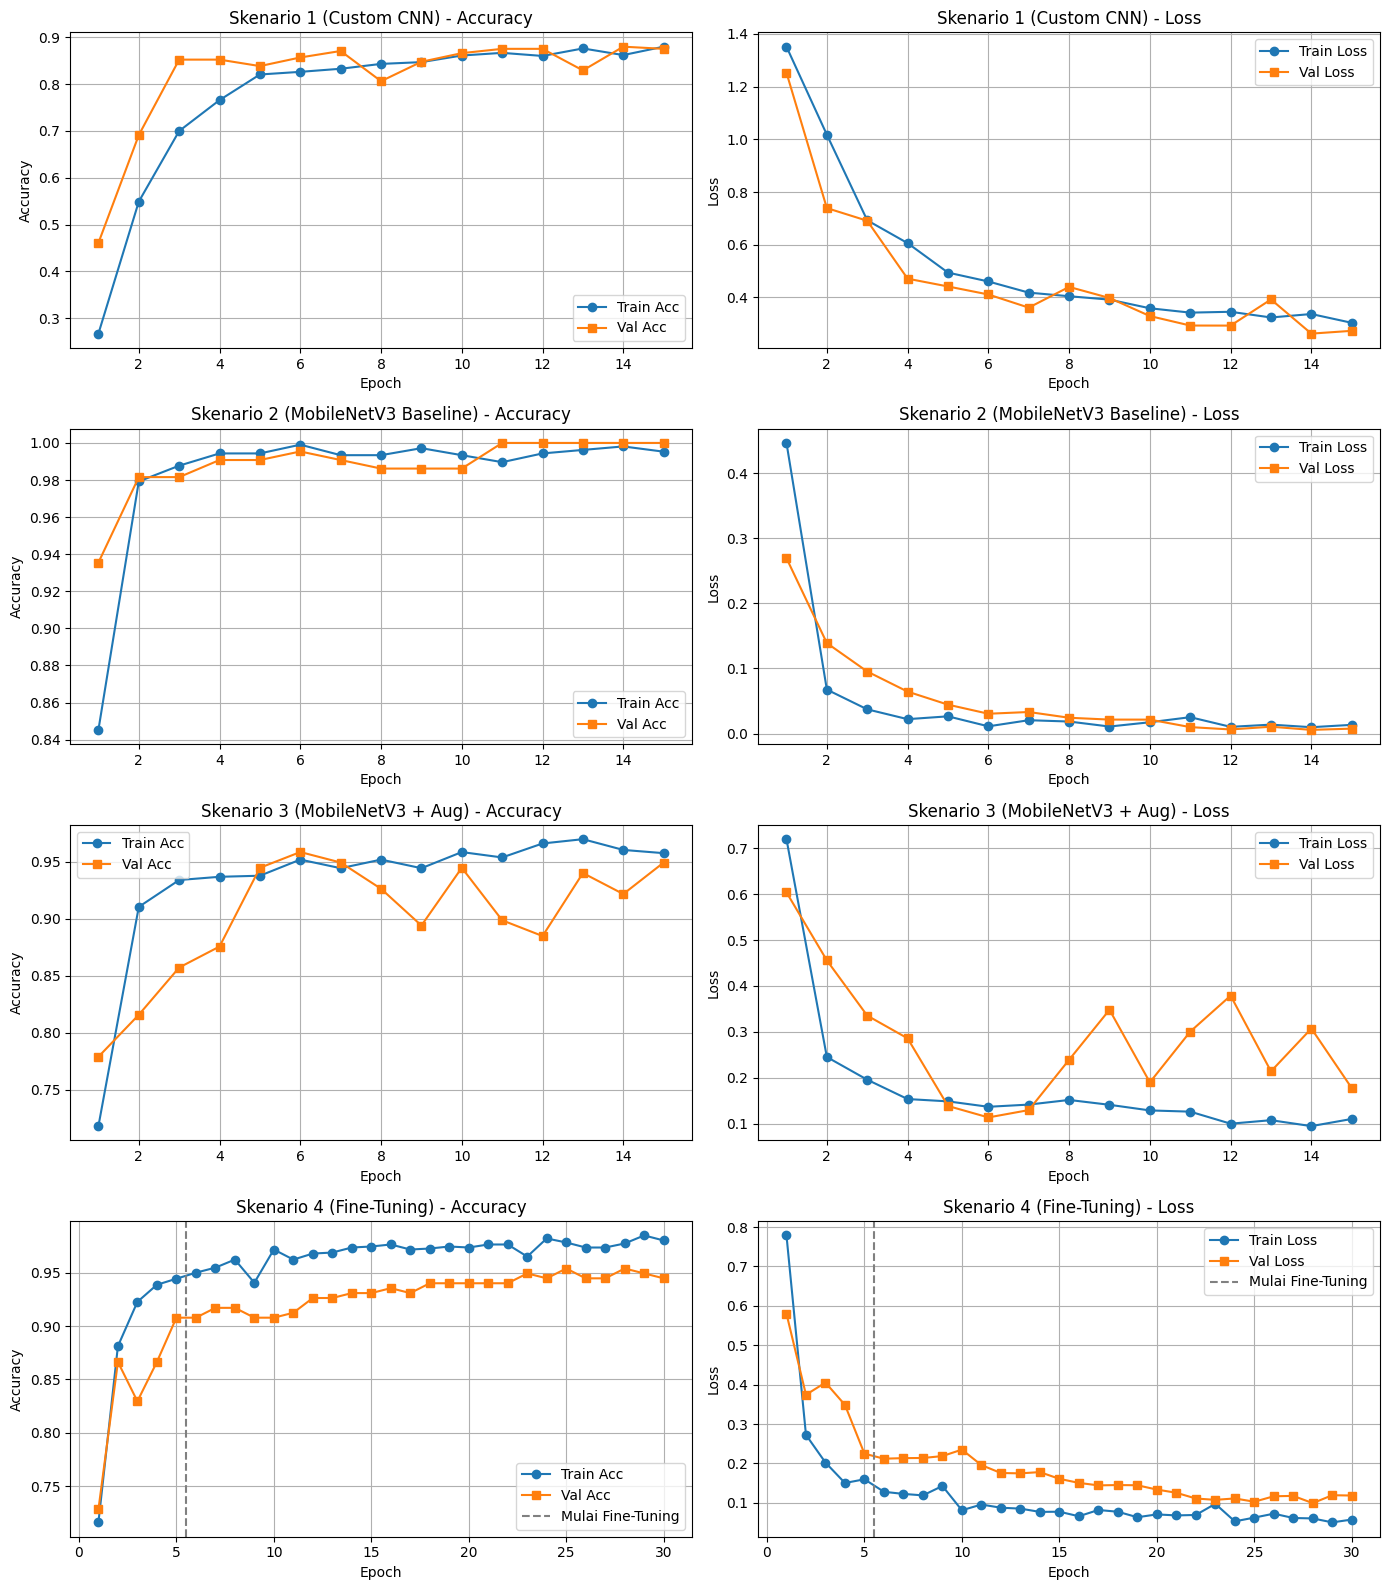


=========== ANALISIS KONVERGENSI & GENERALISASI ===========
Skenario                            | Train Acc | Val Acc   | Gap     | Best Val Ep | Diagnosis
---------------------------------------------------------------------------------------------------------
Skenario 1 (Custom CNN)             | 88.02   % | 87.56   % | 0.46  % | 14          | Good fit
Skenario 2 (MobileNetV3 Baseline)   | 99.53   % | 100.00  % | -0.47 % | 11          | Good fit
Skenario 3 (MobileNetV3 + Aug)      | 95.75   % | 94.93   % | 0.82  % | 6           | Good fit
Skenario 4 (Fine-Tuning)            | 98.02   % | 94.47   % | 3.55  % | 25          | Good fit


In [ ]:
# ================== LEARNING CURVES PER SKENARIO ==================
scenario_names = list(histories.keys())
n_sc = len(scenario_names)

fig, axes = plt.subplots(n_sc, 2, figsize=(14, 4 * n_sc))

for row, name in enumerate(scenario_names):
    hist = histories[name].history
    ep = range(1, len(hist['accuracy']) + 1)

    # Accuracy
    axes[row, 0].plot(ep, hist['accuracy'], 'o-', label='Train Acc')
    axes[row, 0].plot(ep, hist['val_accuracy'], 's-', label='Val Acc')
    axes[row, 0].set_title(f'{name} - Accuracy')
    axes[row, 0].set_xlabel('Epoch'); axes[row, 0].set_ylabel('Accuracy')
    axes[row, 0].grid(True)

    # Loss
    axes[row, 1].plot(ep, hist['loss'], 'o-', label='Train Loss')
    axes[row, 1].plot(ep, hist['val_loss'], 's-', label='Val Loss')
    axes[row, 1].set_title(f'{name} - Loss')
    axes[row, 1].set_xlabel('Epoch'); axes[row, 1].set_ylabel('Loss')
    axes[row, 1].grid(True)

    # Garis batas warm-up -> fine-tuning (khusus Skenario 4)
    if 'Fine-Tuning' in name:
        WARMUP_EPOCHS = 5
        for col in (0, 1):
            axes[row, col].axvline(x=WARMUP_EPOCHS + 0.5, color='gray', linestyle='--',
                                   label='Mulai Fine-Tuning')

    # Legend dipanggil SETELAH semua garis ditambahkan
    axes[row, 0].legend()
    axes[row, 1].legend()

plt.tight_layout()
plt.show()

# ================== ANALISIS OVERFITTING / UNDERFITTING ==================
print("\n=========== ANALISIS KONVERGENSI & GENERALISASI ===========")
print(f"{'Skenario':<35} | {'Train Acc':<9} | {'Val Acc':<9} | {'Gap':<7} | {'Best Val Ep':<11} | Diagnosis")
print("-" * 105)
for name, h in histories.items():
    hist = h.history
    tr_acc, va_acc = hist['accuracy'][-1], hist['val_accuracy'][-1]
    gap = tr_acc - va_acc
    best_ep = int(np.argmax(hist['val_accuracy'])) + 1

    if tr_acc < 0.70 and va_acc < 0.70:
        diag = "Underfitting"
    elif gap > 0.08:
        diag = "Overfitting"
    else:
        diag = "Good fit"
    print(f"{name:<35} | {tr_acc*100:<8.2f}% | {va_acc*100:<8.2f}% | {gap*100:<6.2f}% | {best_ep:<11} | {diag}")

Analisis Sampel Prediksi (Visual Inference / Error Analysis)

Prediksi benar : 221 | Prediksi salah : 1
Rata-rata confidence (benar) : 0.9962
Rata-rata confidence (salah) : 0.9577


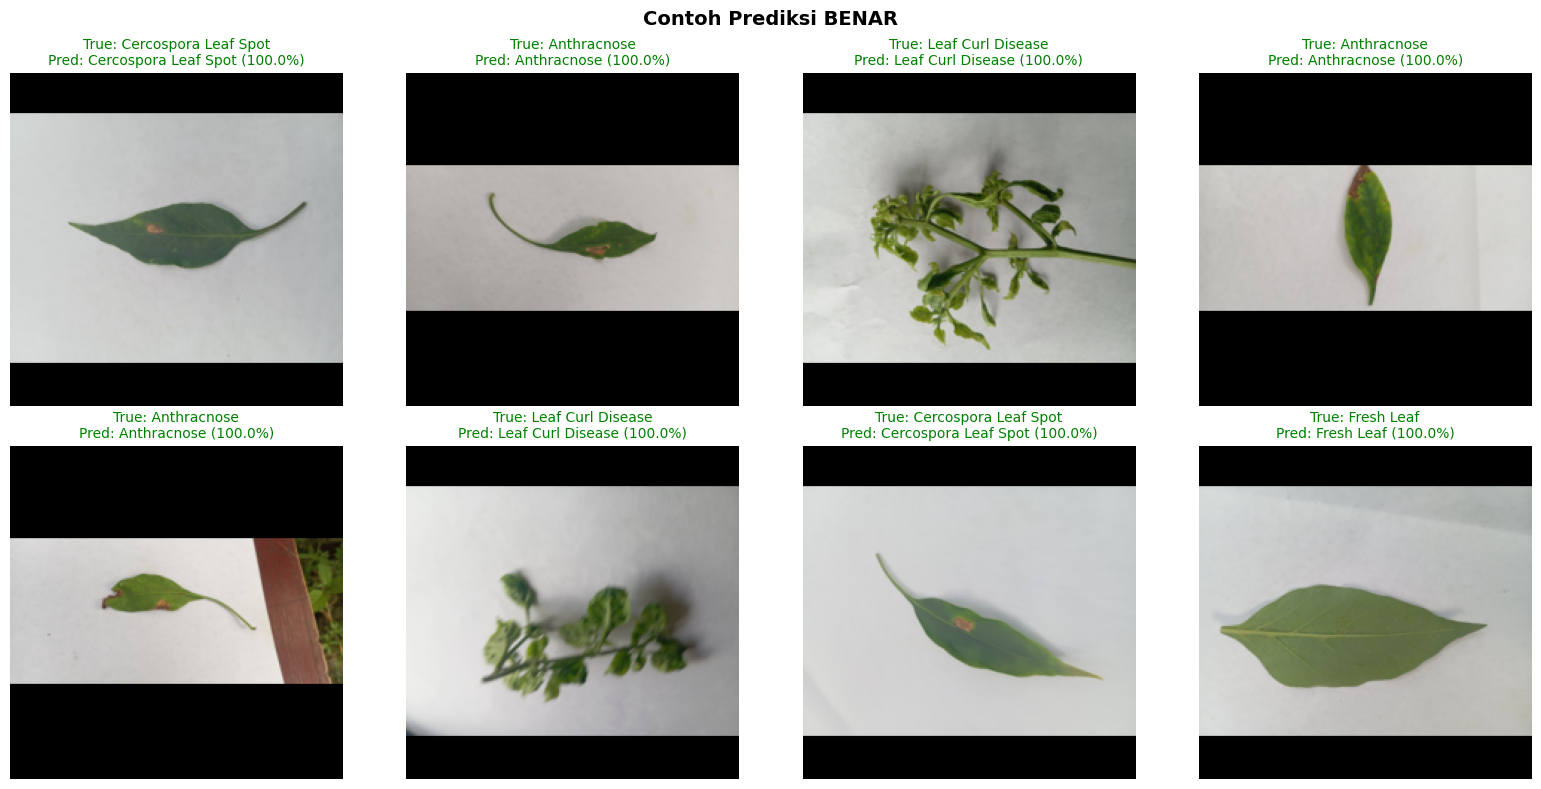

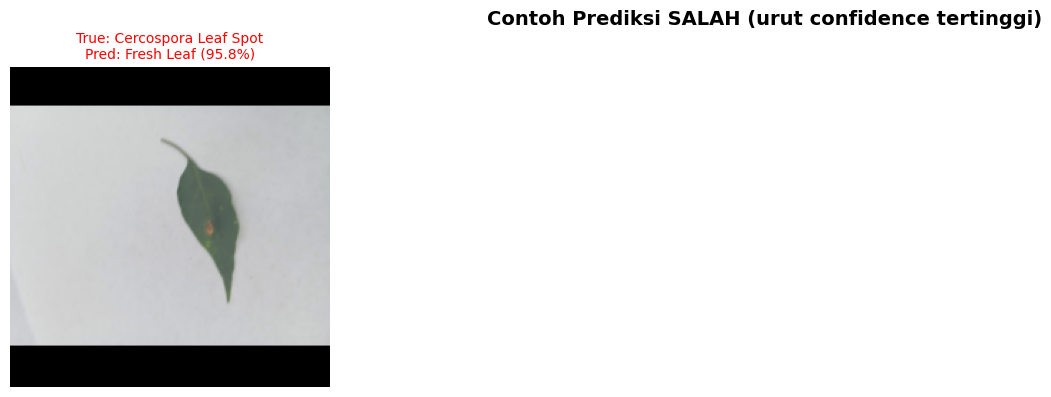


=========== PASANGAN KELAS PALING SERING TERTUKAR ===========
Cercospora Leaf Spot -> diprediksi sebagai Fresh Leaf : 1 citra


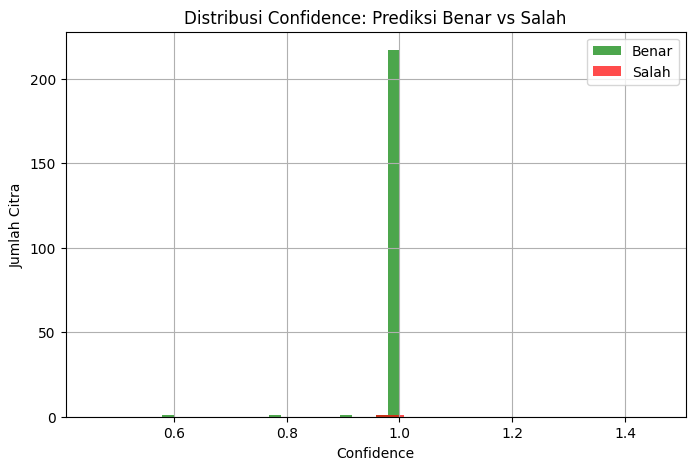

In [ ]:
# ================== PERSIAPAN ==================
confidences = np.max(y_pred_probs, axis=1)
correct_idx = np.where(y_pred == y_test)[0]
wrong_idx   = np.where(y_pred != y_test)[0]

print(f"Prediksi benar : {len(correct_idx)} | Prediksi salah : {len(wrong_idx)}")
print(f"Rata-rata confidence (benar) : {confidences[correct_idx].mean():.4f}")
if len(wrong_idx) > 0:
    print(f"Rata-rata confidence (salah) : {confidences[wrong_idx].mean():.4f}")

def load_img_np(path):
    img, _ = parse_image(path, 0)
    return img.numpy().astype('uint8')

def plot_samples(indices, title, n=8, cols=4):
    indices = indices[:n]
    if len(indices) == 0:
        print(f"[{title}] Tidak ada sampel.")
        return
    rows = int(np.ceil(len(indices) / cols))
    plt.figure(figsize=(4 * cols, 4 * rows))
    for k, idx in enumerate(indices):
        plt.subplot(rows, cols, k + 1)
        plt.imshow(load_img_np(X_test[idx]))
        true_lbl, pred_lbl = class_names[y_test[idx]], class_names[y_pred[idx]]
        color = 'green' if true_lbl == pred_lbl else 'red'
        plt.title(f"True: {true_lbl}\nPred: {pred_lbl} ({confidences[idx]*100:.1f}%)",
                  color=color, fontsize=10)
        plt.axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ================== SAMPEL BENAR (acak) & SALAH (confidence tertinggi) ==================
rng = np.random.default_rng(42)
plot_samples(rng.permutation(correct_idx), "Contoh Prediksi BENAR", n=8)

wrong_sorted = wrong_idx[np.argsort(-confidences[wrong_idx])]  # salah tapi paling yakin
plot_samples(wrong_sorted, "Contoh Prediksi SALAH (urut confidence tertinggi)", n=8)

# ================== PASANGAN KELAS YANG PALING SERING TERTUKAR ==================
cm = confusion_matrix(y_test, y_pred)
pairs = [(cm[i, j], class_names[i], class_names[j])
         for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i != j and cm[i, j] > 0]
pairs.sort(reverse=True)

print("\n=========== PASANGAN KELAS PALING SERING TERTUKAR ===========")
for cnt, t, p in pairs[:5]:
    print(f"{t} -> diprediksi sebagai {p} : {cnt} citra")
if not pairs:
    print("Tidak ada kesalahan klasifikasi.")

# ================== DISTRIBUSI CONFIDENCE ==================
plt.figure(figsize=(8, 5))
plt.hist(confidences[correct_idx], bins=20, alpha=0.7, label='Benar', color='green')
if len(wrong_idx) > 0:
    plt.hist(confidences[wrong_idx], bins=20, alpha=0.7, label='Salah', color='red')
plt.xlabel('Confidence'); plt.ylabel('Jumlah Citra')
plt.title('Distribusi Confidence: Prediksi Benar vs Salah')
plt.legend(); plt.grid(True)
plt.show()

Visualisasi Interpretabilitas Model (Grad-CAM)

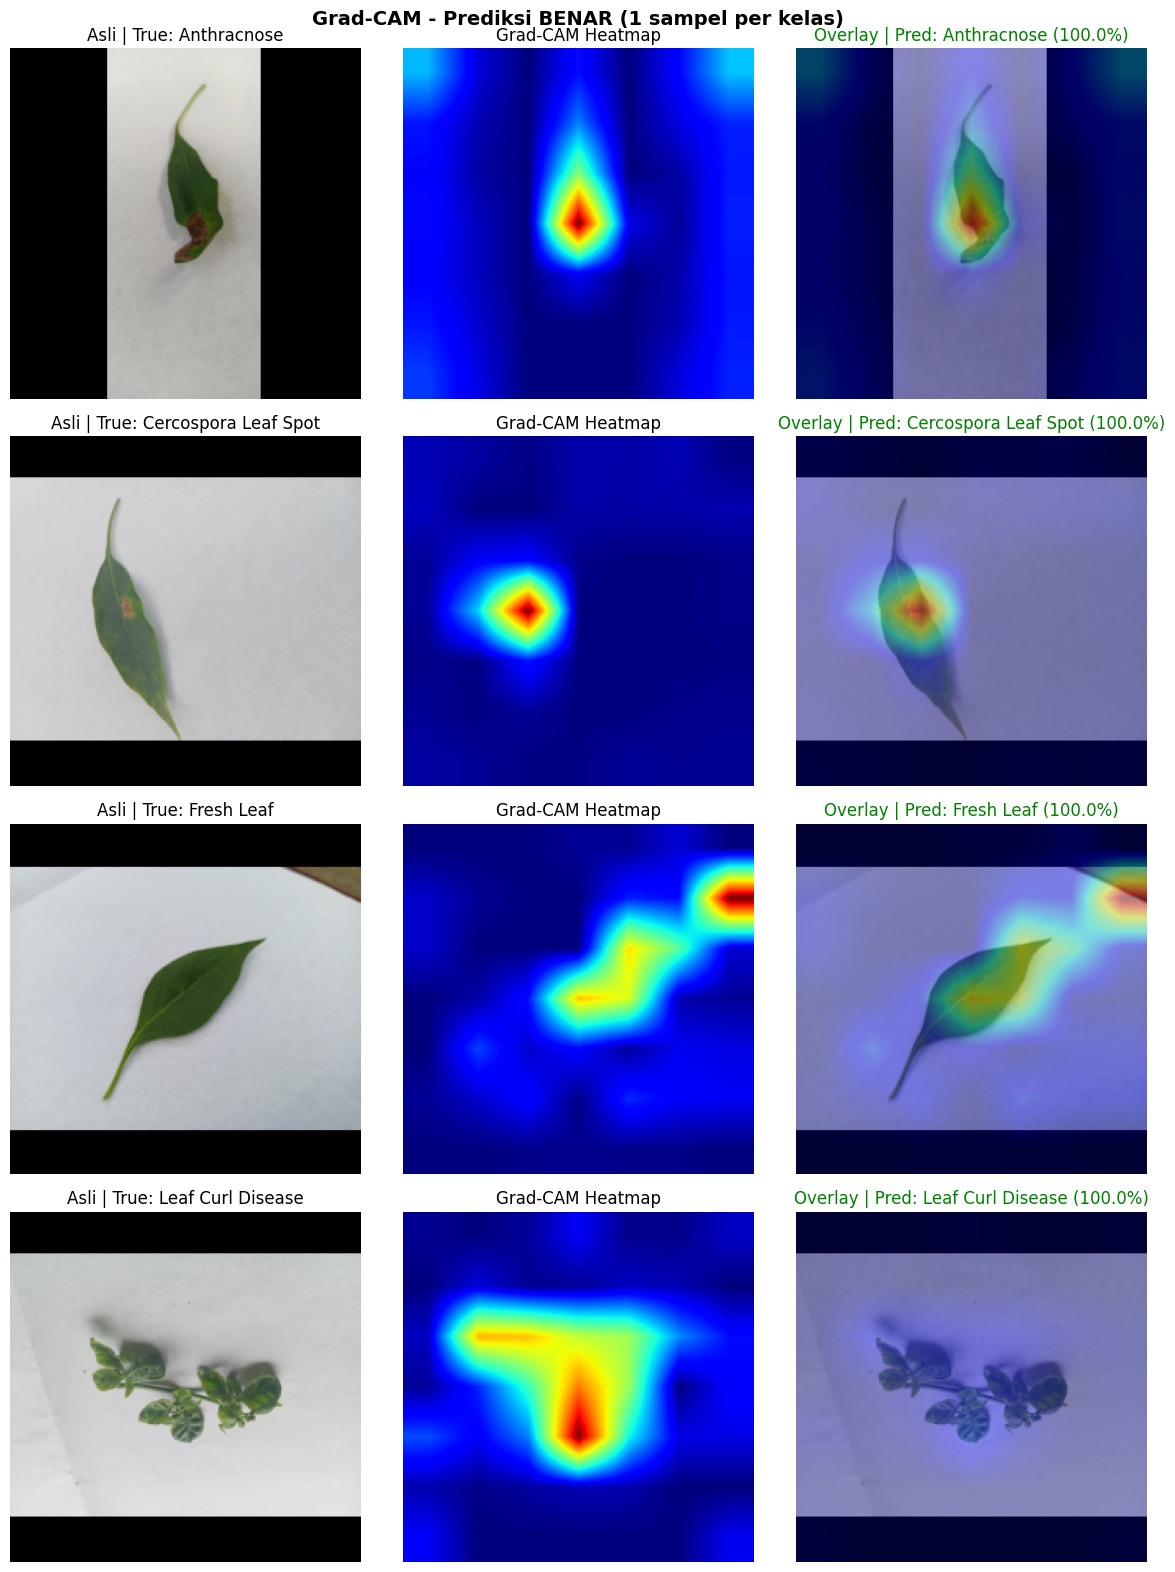

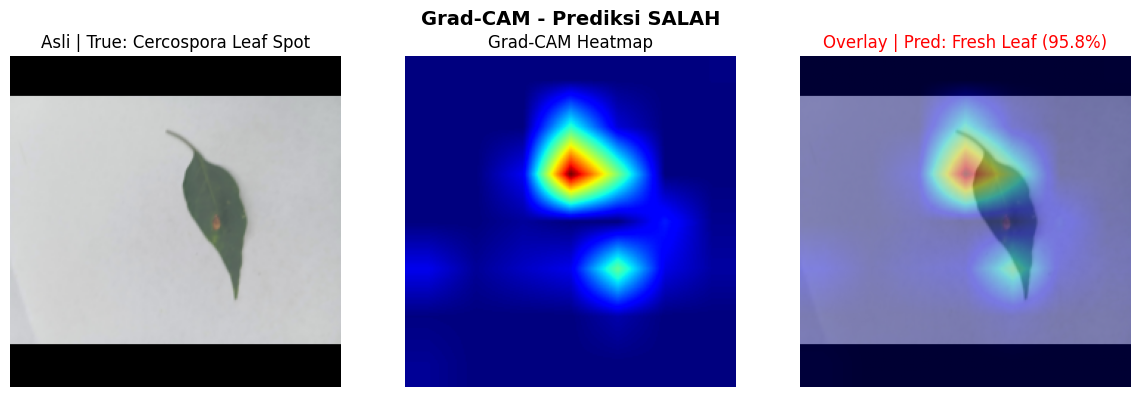

In [ ]:
import matplotlib.cm as mpl_cm

def get_gradcam_heatmap(model, img_array, pred_index=None):
    """img_array: (1, 224, 224, 3). Mengembalikan heatmap (h, w) 0-1 dan probabilitas."""
    base_idx = [i for i, l in enumerate(model.layers) if isinstance(l, tf.keras.Model)][0]
    base = model.layers[base_idx]
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        x = img_tensor
        for layer in model.layers[1:base_idx]:        # augmentasi/preprocess (inaktif saat inference)
            x = layer(x, training=False)
        conv_out = base(x, training=False)            # feature map konvolusi terakhir
        tape.watch(conv_out)
        x = conv_out
        for layer in model.layers[base_idx + 1:]:     # classification head
            x = layer(x, training=False)
        preds = x
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_score = preds[:, pred_index]

    grads = tape.gradient(class_score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.squeeze(conv_out[0] @ pooled_grads[..., tf.newaxis])
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), preds.numpy()

def overlay_heatmap(img, heatmap, alpha=0.4):
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (224, 224)).numpy().squeeze()
    jet = plt.get_cmap('jet')(heatmap_resized)[..., :3]
    return np.clip((1 - alpha) * (img / 255.0) + alpha * jet, 0, 1), heatmap_resized

def show_gradcam(model, indices, title):
    if len(indices) == 0:
        print(f"[{title}] Tidak ada sampel.")
        return
    fig, axes = plt.subplots(len(indices), 3, figsize=(12, 4 * len(indices)))
    axes = np.atleast_2d(axes)
    for r, idx in enumerate(indices):
        img = load_img_np(X_test[idx])
        heatmap, probs = get_gradcam_heatmap(model, np.expand_dims(img, 0))
        overlay, hm_resized = overlay_heatmap(img, heatmap)

        pred_cls = int(np.argmax(probs[0]))
        color = 'green' if pred_cls == y_test[idx] else 'red'

        axes[r, 0].imshow(img)
        axes[r, 0].set_title(f"Asli | True: {class_names[y_test[idx]]}")
        axes[r, 1].imshow(hm_resized, cmap='jet')
        axes[r, 1].set_title("Grad-CAM Heatmap")
        axes[r, 2].imshow(overlay)
        axes[r, 2].set_title(f"Overlay | Pred: {class_names[pred_cls]} ({probs[0][pred_cls]*100:.1f}%)",
                             color=color)
        for c in range(3):
            axes[r, c].axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# --- Satu sampel benar per kelas ---
gradcam_correct = []
for c in range(NUM_CLASSES):
    idx_c = [i for i in correct_idx if y_test[i] == c]
    if idx_c:
        gradcam_correct.append(idx_c[0])
show_gradcam(best_model, gradcam_correct, "Grad-CAM - Prediksi BENAR (1 sampel per kelas)")

# --- Sampel salah (maks. 4, confidence tertinggi) ---
show_gradcam(best_model, list(wrong_sorted[:4]), "Grad-CAM - Prediksi SALAH")